In [ ]:
import sys
import os
# Tell Python to step out of the notebooks folder and look at the main project folder
sys.path.append(os.path.abspath(".."))

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import your custom modularized pipeline blocks from the src directory
from src.preprocess import process_pair
from src.predict import filter_probable_microplastics

# Define local relative paths (assumes your notebook is inside the 'notebooks' folder)
# '../' tells python to step out of the notebooks folder to find the data folder
img_off_path = "../data/sample_led_off.jpg" 
img_on_path = "../data/sample_led_on.jpg"

# Read the images from your local hard drive
img_off = cv2.imread(img_off_path, cv2.IMREAD_COLOR)
img_on = cv2.imread(img_on_path, cv2.IMREAD_COLOR)

# Verification check to make sure paths are correct and images loaded
if img_off is None or img_on is None:
    raise FileNotFoundError("Could not find the target images! Please verify your files are in the 'data/' folder.")
else:
    print("✅ Images loaded successfully from local storage!")

✅ Images loaded successfully from local storage!


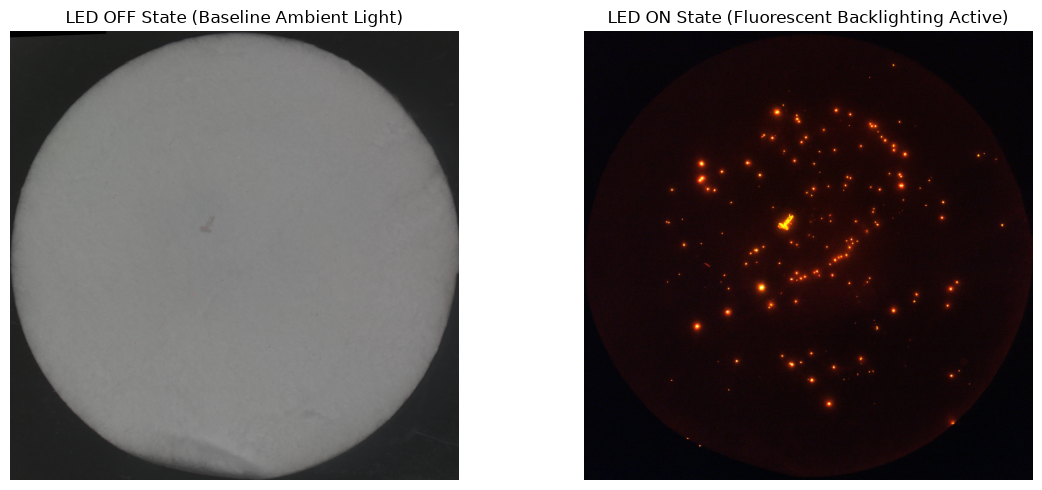

🔍 Raw analysis tracked 130 candidate particles.


In [7]:
# 1. Ensure both images are treated as 3-channel BGR matrices to avoid index crashes
if len(img_off.shape) == 2:
    img_off = cv2.cvtColor(img_off, cv2.COLOR_GRAY2BGR)
if len(img_on.shape) == 2:
    img_on = cv2.cvtColor(img_on, cv2.COLOR_GRAY2BGR)

# 2. Dynamic resizing safeguard: makes sure pixel grids match identically for subtraction
if img_off.shape != img_on.shape:
    img_on = cv2.resize(img_on, (img_off.shape[1], img_off.shape[0]))

# 3. Execute the core morphological pipeline
annotated_raw, df_raw, mask = process_pair(img_off, img_on)

# 4. Plot the side-by-side comparative lighting analysis
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_off, cv2.COLOR_BGR2RGB))
plt.title("LED OFF State (Baseline Ambient Light)", fontsize=12)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_on, cv2.COLOR_BGR2RGB))
plt.title("LED ON State (Fluorescent Backlighting Active)", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

# 5. Display the unrefined extraction sheet 
print(f"🔍 Raw analysis tracked {len(df_raw)} candidate particles.")

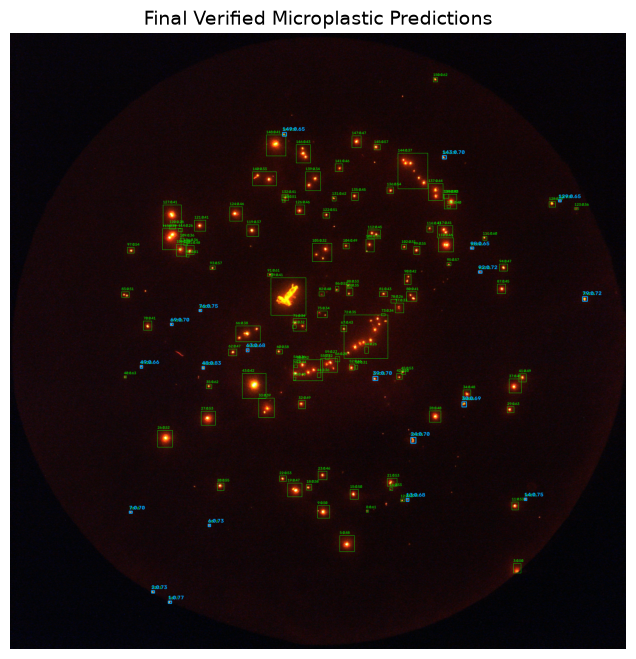


============================== FINAL DETECTED LOG ==============================
 id     type  area_px  confidence  solidity  aspect_ratio
  1 fragment     42.5    0.773493  0.923913      1.375000
  2     bead     43.5    0.734873  0.956044      1.250000
  6     bead     32.0    0.732484  0.941176      1.000000
  7     bead     34.0    0.695481  1.000000      1.428571
 13     bead     46.5    0.681522  0.877358      0.900000
 14     bead     35.5    0.753299  0.972603      1.000000
 24 fragment    177.5    0.698431  0.801354      0.894737
 30 fragment    141.5    0.685308  0.832353      0.882353
 39 fragment    104.5    0.698107  0.832669      1.230769
 48     bead     42.0    0.830617  0.933333      0.888889
 49     bead     37.5    0.660112  0.882353      0.888889
 63 fragment     38.0    0.681120  0.904762      0.900000
 69     bead     41.0    0.701946  0.976190      1.125000
 76     bead     32.0    0.754183  0.984615      1.285714
 79 fragment    138.0    0.718193  0.867925     

In [8]:
# 1. Run your predictive threshold criteria engine
probable_img, probable_df = filter_probable_microplastics(
    df_raw, annotated_raw,
    conf_thresh=0.65,
    area_thresh=30,
    circ_thresh=0.5,
    solidity_thresh=0.75,
    extent_thresh=0.4,
    aspect_ratio_max=4.0,
    box_color=(255, 165, 0) # High-contrast Orange Bounding Boxes
)

# 2. Final Output Reporting
if probable_df.empty:
    print("❌ No high-probability microplastics detected passing your strict thresholds.")
else:
    # Plot the crisp, polished computer vision annotations
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(probable_img, cv2.COLOR_BGR2RGB))
    plt.title("Final Verified Microplastic Predictions", fontsize=14)
    plt.axis("off")
    plt.show()

    # Print out a beautifully structured data matrix for your portfolio
    print("\n" + "="*30 + " FINAL DETECTED LOG " + "="*30)
    print(probable_df[["id", "type", "area_px", "confidence", "solidity", "aspect_ratio"]].to_string(index=False))
    print("="*80)